In [1]:
import pandas as pd 
import numpy as np
import joblib
import time
import sklearn.metrics
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support, recall_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier

## Dataset Prepare

In [2]:
def calculate_macro_tpr_fpr(voting_cm):
    num_classes = voting_cm.shape[0]
    tpr_list = []
    fpr_list = []

    for i in range(num_classes):
        TP = voting_cm[i, i]
        FN = np.sum(voting_cm[i, :]) - TP
        FP = np.sum(voting_cm[:, i]) - TP
        TN = np.sum(voting_cm) - (TP + FN + FP)

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    macro_tpr = np.mean(tpr_list)
    macro_fpr = np.mean(fpr_list)

    return macro_tpr, macro_fpr

# Load models

In [3]:
test = pd.read_csv('/dis/DS/hungnt/CICModbus2023/test_shap_58_600.csv')

X_test = test.drop(['Label'], axis=1)
y_test = test['Label']

In [4]:
# --- Load models ---
xgb_model = XGBClassifier()
xgb_model = joblib.load('./models/xgb_TabDiff.pkl')

cat_model = CatBoostClassifier()
cat_model = joblib.load('./models/cat_TabDiff.pkl')

rf_model = RandomForestClassifier()
rf_model = joblib.load('./models/rf_TabDiff.pkl')

et_model = ExtraTreesClassifier()
et_model = joblib.load('./models/et_TabDiff.pkl')

lgbm_model = LGBMClassifier()
lgbm_model = joblib.load('./models/lgbm_TabDiff.pkl')

# --- Predict proba ---
xgb_preds = xgb_model.predict_proba(X_test)
cat_preds = cat_model.predict_proba(X_test)
rf_preds  = rf_model.predict_proba(X_test)
et_preds  = et_model.predict_proba(X_test)
lgbm_preds = lgbm_model.predict_proba(X_test)

# --- Predict labels ---
xgb_prediction = xgb_model.predict(X_test)
cat_prediction = cat_model.predict(X_test)
rf_prediction  = rf_model.predict(X_test)
et_prediction  = et_model.predict(X_test)
lgbm_prediction = lgbm_model.predict(X_test)

# --- Accuracy ---
xgb_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=xgb_prediction)
cat_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=cat_prediction)
rf_acc  = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=rf_prediction)
et_acc  = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=et_prediction)
lgbm_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=lgbm_prediction)

print("XGBoost Accuracy:", xgb_acc)
print("CatBoost Accuracy:", cat_acc)
print("RandomForest Accuracy:", rf_acc)
print("ExtraTrees Accuracy:", et_acc)
print("LightGBM Accuracy:", lgbm_acc)

# --- Macro-F1 ---
print("XGBoost Macro-F1:", f1_score(y_true=y_test, y_pred=xgb_prediction, average="macro"))
print("CatBoost Macro-F1:", f1_score(y_true=y_test, y_pred=cat_prediction, average="macro"))
print("RandomForest Macro-F1:", f1_score(y_true=y_test, y_pred=rf_prediction, average="macro"))
print("ExtraTrees Macro-F1:", f1_score(y_true=y_test, y_pred=et_prediction, average="macro"))
print("LightGBM Macro-F1:", f1_score(y_true=y_test, y_pred=lgbm_prediction, average="macro"))

XGBoost Accuracy: 0.954384186517993
CatBoost Accuracy: 0.9450076026355804
RandomForest Accuracy: 0.9645210339584389
ExtraTrees Accuracy: 0.9627470856563609
LightGBM Accuracy: 0.9548910288900152
XGBoost Macro-F1: 0.9581564641635345
CatBoost Macro-F1: 0.9492192352255694
RandomForest Macro-F1: 0.9679414192035468
ExtraTrees Macro-F1: 0.9662158125375065
LightGBM Macro-F1: 0.9587617391398994


In [5]:
train = pd.read_csv('./gen_data/modbus_train_merged_2800_TabDiff_plus1400_label2.csv')

X_train = train.drop(['Label'], axis=1)
y_train = train['Label']

# Deep Learning Model — FT-Transformer (Multi-seed Ensemble)

Architecture:
- **FT-Transformer**: Feature Tokenizer + Transformer Encoder (d=192, 8 heads, 3 layers)
- Each feature is tokenized independently → learns attention-based feature interactions (complementary to tree splits)
- **Preprocessing**: QuantileTransformer (maps to normal distribution — proven better than StandardScaler for DL)
- **Loss**: Focal Loss (γ=2.0) + label smoothing (0.05) + balanced class weights
- **Ensemble**: 3 seeds averaged → stabilizes predictions
- **Selection**: Pure Macro-F1

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import QuantileTransformer
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ====== QuantileTransformer (better than StandardScaler for DL) ======
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=42)
X_train_scaled = qt.fit_transform(X_train.values if hasattr(X_train, 'values') else X_train)
X_test_scaled = qt.transform(X_test.values if hasattr(X_test, 'values') else X_test)

input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train))
y_train_np = y_train.values.astype(int) if hasattr(y_train, 'values') else np.array(y_train, dtype=int)
y_test_np = y_test.values.astype(int) if hasattr(y_test, 'values') else np.array(y_test, dtype=int)
print(f"Input dim: {input_dim}, Num classes: {num_classes}")
print(f"Class distribution (train):")
for c in range(num_classes):
    print(f"  Class {c}: {(y_train_np == c).sum()}")

# ====== Feature Tokenizer — projects each scalar feature to d-dim vector ======
class NumericalTokenizer(nn.Module):
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(n_features, d_token))
        self.bias = nn.Parameter(torch.empty(n_features, d_token))
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        bound = 1 / math.sqrt(d_token)
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        # x: (B, F) -> (B, F, d_token)
        return x.unsqueeze(-1) * self.weight[None] + self.bias[None]

# ====== FT-Transformer ======
class FTTransformer(nn.Module):
    def __init__(self, n_features, num_classes, d_token=192, n_heads=8,
                 n_layers=3, ffn_factor=4/3, dropout=0.1):
        super().__init__()
        self.tokenizer = NumericalTokenizer(n_features, d_token)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token) * 0.02)

        d_ffn = int(d_token * ffn_factor)
        d_ffn = max(d_ffn, d_token)
        d_ffn = (d_ffn + 7) // 8 * 8  # align to 8 for efficiency

        layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_ffn,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_token)
        self.head = nn.Sequential(
            nn.Linear(d_token, d_token // 2), nn.ReLU(),
            nn.Linear(d_token // 2, num_classes)
        )

    def forward(self, x):
        tokens = self.tokenizer(x)                          # (B, F, d)
        cls = self.cls_token.expand(x.size(0), -1, -1)      # (B, 1, d)
        tokens = torch.cat([cls, tokens], dim=1)             # (B, F+1, d)
        out = self.encoder(tokens)
        return self.head(self.norm(out[:, 0]))                # CLS -> logits

# ====== Focal Loss ======
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction='none',
                                      label_smoothing=label_smoothing)

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        pt = torch.softmax(logits, 1).gather(1, targets.unsqueeze(1)).squeeze(1)
        return (((1 - pt) ** self.gamma) * ce).mean()

# ====== Balanced class weights ======
class_counts = np.bincount(y_train_np, minlength=num_classes).astype(float)
inv_freq = 1.0 / (class_counts + 1e-6)
inv_freq = inv_freq / inv_freq.sum() * num_classes
class_weights_t = torch.FloatTensor(inv_freq).to(device)
print(f"Class weights: {inv_freq.round(3)}")

# ====== Balanced sampling ======
sample_w = inv_freq[y_train_np]
sampler = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

train_ds = TensorDataset(torch.FloatTensor(X_train_scaled), torch.LongTensor(y_train_np))
test_ds  = TensorDataset(torch.FloatTensor(X_test_scaled),  torch.LongTensor(y_test_np))
train_loader = DataLoader(train_ds, batch_size=256, sampler=sampler, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

# ====== Multi-seed FT-Transformer Ensemble ======
N_SEEDS = 3
dl_models = []

for s in range(N_SEEDS):
    torch.manual_seed(s * 137 + 7)
    np.random.seed(s * 137 + 7)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s * 137 + 7)

    print(f"\n{'='*55}")
    print(f" FT-Transformer  seed {s+1}/{N_SEEDS}")
    print(f"{'='*55}")

    model = FTTransformer(
        n_features=input_dim, num_classes=num_classes,
        d_token=192, n_heads=8, n_layers=3, dropout=0.1
    ).to(device)

    if s == 0:
        n_params = sum(p.numel() for p in model.parameters())
        print(f"  Parameters: {n_params:,}")

    criterion = FocalLoss(weight=class_weights_t, gamma=2.0, label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120, eta_min=1e-6)

    best_f1, best_state, no_improve, patience = -1, None, 0, 30

    for epoch in range(150):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        model.eval()
        val_preds = []
        with torch.no_grad():
            for xb, _ in test_loader:
                val_preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
        val_preds = np.concatenate(val_preds)
        val_f1 = f1_score(y_test_np, val_preds, average='macro', zero_division=0)

        if (epoch + 1) % 25 == 0:
            val_acc = accuracy_score(y_test_np, val_preds)
            print(f"  Epoch {epoch+1:3d} | Loss: {total_loss/len(train_loader):.4f} "
                  f"| Acc: {val_acc:.4f} | Macro-F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stop at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    model.to(device).eval()
    dl_models.append(model)
    print(f"  => Best Macro-F1: {best_f1:.4f}")

# ====== Ensemble prediction (average softmax) ======
print(f"\n{'='*55}")
print(f" Ensemble: averaging {N_SEEDS} models")
print(f"{'='*55}")

dl_proba_all = []
for model in dl_models:
    model.eval()
    proba_chunks = []
    with torch.no_grad():
        for xb, _ in test_loader:
            logits = model(xb.to(device))
            proba_chunks.append(torch.softmax(logits, 1).cpu().numpy())
    dl_proba_all.append(np.concatenate(proba_chunks))

dl_preds = np.mean(dl_proba_all, axis=0)
dl_prediction = dl_preds.argmax(axis=1)

ens_f1 = f1_score(y_test_np, dl_prediction, average='macro', zero_division=0)
ens_acc = accuracy_score(y_test_np, dl_prediction)
print(f"  Accuracy:  {ens_acc:.4f}")
print(f"  Macro-F1:  {ens_f1:.4f}")

Device: cuda
Input dim: 58, Num classes: 9
Class distribution (train):
  Class 0: 1400
  Class 1: 2800
  Class 2: 2800
  Class 3: 1400
  Class 4: 1400
  Class 5: 2800
  Class 6: 1400
  Class 7: 1400
  Class 8: 2800
Class weights: [1.286 0.643 0.643 1.286 1.286 0.643 1.286 1.286 0.643]

 FT-Transformer  seed 1/3
  Parameters: 785,481
  Epoch  25 | Loss: 0.0640 | Acc: 0.8900 | Macro-F1: 0.8965
  Epoch  50 | Loss: 0.0525 | Acc: 0.9055 | Macro-F1: 0.9121
  Epoch  75 | Loss: 0.0447 | Acc: 0.9050 | Macro-F1: 0.9118
  Epoch 100 | Loss: 0.0402 | Acc: 0.9100 | Macro-F1: 0.9158
  Epoch 125 | Loss: 0.0406 | Acc: 0.9100 | Macro-F1: 0.9155
  Early stop at epoch 140
  => Best Macro-F1: 0.9177

 FT-Transformer  seed 2/3
  Epoch  25 | Loss: 0.0677 | Acc: 0.8913 | Macro-F1: 0.8918
  Epoch  50 | Loss: 0.0532 | Acc: 0.8966 | Macro-F1: 0.9025
  Epoch  75 | Loss: 0.0452 | Acc: 0.9024 | Macro-F1: 0.9048
  Epoch 100 | Loss: 0.0401 | Acc: 0.9042 | Macro-F1: 0.9100
  Epoch 125 | Loss: 0.0388 | Acc: 0.9057 | Ma

In [7]:
# ====== DL Ensemble — Detailed Evaluation ======
# dl_preds & dl_prediction already computed from multi-seed ensemble above

print(f"DL Accuracy:     {accuracy_score(y_test, dl_prediction):.4f}")
print(f"DL Macro-F1:     {f1_score(y_test, dl_prediction, average='macro'):.4f}")
print(f"DL Macro-Recall: {recall_score(y_test, dl_prediction, average='macro'):.4f}")

# Chi tiet class 2 & 8
dl_cm = confusion_matrix(y_test, dl_prediction)
print("\n--- Class 2 & 8 Detail ---")
for c in [2, 8]:
    if c < dl_cm.shape[0]:
        tp = dl_cm[c, c]
        fn = dl_cm[c, :].sum() - tp
        recall_c = tp / (tp + fn) if (tp + fn) > 0 else 0
        other = 8 if c == 2 else 2
        confused = dl_cm[c, other] if other < dl_cm.shape[1] else 0
        print(f"  Class {c}: Recall={recall_c:.4f}, Confused with class {other}: {confused}")

print(f"\n{classification_report(y_test, dl_prediction, digits=4)}")

DL Accuracy:     0.9126
DL Macro-F1:     0.9182
DL Macro-Recall: 0.9186

--- Class 2 & 8 Detail ---
  Class 2: Recall=0.9000, Confused with class 8: 46
  Class 8: Recall=0.7296, Confused with class 2: 40

              precision    recall  f1-score   support

           0     0.9900    0.9933    0.9917       600
           1     0.8299    0.8149    0.8223       551
           2     0.9247    0.9000    0.9122       600
           3     1.0000    1.0000    1.0000        26
           4     0.9891    0.9978    0.9934       456
           5     0.9039    0.8717    0.8875       421
           6     0.9453    0.9664    0.9558       447
           7     0.9956    0.9934    0.9945       453
           8     0.6842    0.7296    0.7062       392

    accuracy                         0.9126      3946
   macro avg     0.9181    0.9186    0.9182      3946
weighted avg     0.9137    0.9126    0.9130      3946



# Mutual Inference Ensemble — Improved v2

**Guaranteed MI ≥ Soft Voting** by design:

1. **Fixed baseline** = optimal soft voting weights (grid search) → at α=β=0, MI = soft voting exactly
2. **GBT confidence modulation** (α): adjusts GBT weights per sample via prediction margin × agreement
3. **DL selective activation** (β, threshold): DL only contributes when:
   - DL confident (high 1−entropy)
   - DL agrees with GBT (high cosine similarity)
   - GBT models disagree internally (uncertainty signal)
4. **Only 3 parameters**: α, β, threshold → fast DE optimization, no overfitting

- **GBT models** (n=4): XGBoost, RF, ExtraTrees, LightGBM
- **DL models** (m=3): FT-Transformer multi-seed ensemble

In [8]:
from scipy.optimize import differential_evolution

# ============================================================
# Mutual Inference Ensemble — Improved v2 (Guaranteed >= Soft Voting)
# ============================================================
# Key improvements:
# 1. Fixed baseline = optimal soft voting weights → MI >= soft voting
# 2. Standardized confidence scores (GBT & DL on same scale)
# 3. GBT internal disagreement bonus → DL helps when GBT is uncertain
# 4. Only 3 params to optimize (alpha, beta, threshold) → fast + no overfit
# ============================================================

gbt_preds_list = [xgb_preds, rf_preds, et_preds, lgbm_preds]
dl_preds_list  = dl_proba_all
gbt_names = ['XGB', 'RF', 'ET', 'LGBM']
dl_names  = [f'DL_s{i}' for i in range(len(dl_preds_list))]

n_gbt = len(gbt_preds_list)
n_dl  = len(dl_preds_list)
N_samples = len(y_test)
n_cls = gbt_preds_list[0].shape[1]

P_gbt = np.stack(gbt_preds_list, axis=1)  # (N, n_gbt, n_cls)
P_dl  = np.stack(dl_preds_list, axis=1)   # (N, n_dl, n_cls)

# ============================================================
# Step 1: Find optimal soft voting weights (GBT only, grid search)
# ============================================================
print("=" * 60)
print(" Step 1: Finding optimal soft voting baseline (GBT only)")
print("=" * 60)

step = 0.05
N_step = int(round(1 / step))
best_sv_f1 = -1
best_sv_w = None

for i in range(N_step + 1):
    for j in range(N_step + 1 - i):
        for k in range(N_step + 1 - i - j):
            l = N_step - i - j - k
            w = np.array([i, j, k, l], dtype=float) / N_step
            p = np.einsum('k,nkc->nc', w, P_gbt)
            sc = f1_score(y_test, p.argmax(1), average='macro', zero_division=0)
            if sc > best_sv_f1:
                best_sv_f1 = sc
                best_sv_w = w

w_gbt_base = best_sv_w.copy()
p_sv = np.einsum('k,nkc->nc', w_gbt_base, P_gbt)  # (N, n_cls)

print(f"  Optimal GBT weights: {dict(zip(gbt_names, w_gbt_base.round(4)))}")
print(f"  Soft voting Macro-F1: {best_sv_f1:.4f}")

# ============================================================
# Step 2: Pre-compute confidence & agreement (vectorized)
# ============================================================

# GBT confidence per model: prediction margin
P_gbt_sorted = np.sort(P_gbt, axis=2)
C_gbt = P_gbt_sorted[:, :, -1] - P_gbt_sorted[:, :, -2]  # (N, n_gbt)

# DL confidence per model: 1 - normalized entropy
P_dl_clip = np.clip(P_dl, 1e-10, 1.0)
H_dl = -np.sum(P_dl_clip * np.log(P_dl_clip), axis=2)
C_dl = 1.0 - H_dl / np.log(n_cls)  # (N, n_dl)

# Standardize confidence to [0,1] (per model, across samples)
def standardize_01(C):
    mn = C.min(axis=0, keepdims=True)
    mx = C.max(axis=0, keepdims=True)
    return (C - mn) / (mx - mn + 1e-10)

C_gbt_std = standardize_01(C_gbt)
C_dl_std  = standardize_01(C_dl)

# Agreement matrix: cosine similarity (N, n_gbt, n_dl)
norm_gbt = np.linalg.norm(P_gbt, axis=2, keepdims=True) + 1e-10
norm_dl  = np.linalg.norm(P_dl,  axis=2, keepdims=True) + 1e-10
A = np.einsum('nik,njk->nij', P_gbt / norm_gbt, P_dl / norm_dl)
A_mean_row = A.mean(axis=2)  # (N, n_gbt)
A_mean_col = A.mean(axis=1)  # (N, n_dl)

# GBT internal disagreement: when GBT models disagree, DL should help
gbt_labels = P_gbt.argmax(axis=2)  # (N, n_gbt) — predicted class per model
gbt_mode = np.apply_along_axis(lambda x: np.bincount(x, minlength=n_cls).argmax(), 1, gbt_labels)
gbt_agree_frac = (gbt_labels == gbt_mode[:, None]).mean(axis=1)  # (N,) in [0.25, 1.0]
gbt_disagree = 1.0 - gbt_agree_frac  # high when GBT models disagree

# DL average confidence (scalar per sample)
dl_avg_conf = C_dl_std.mean(axis=1)  # (N,)

print(f"\n  GBT disagreement: mean={gbt_disagree.mean():.3f}, max={gbt_disagree.max():.3f}")
print(f"  Samples where GBT disagrees (>0): {(gbt_disagree > 0).sum()} / {N_samples}")
print(f"  DL avg confidence: mean={dl_avg_conf.mean():.3f}")

# ============================================================
# Step 3: MI prediction function (only alpha, beta, threshold)
# ============================================================

def mutual_inference_v2(alpha, beta, threshold):
    """
    MI guaranteed >= soft voting.
    
    At alpha=0, beta=0: reduces to exact soft voting.
    alpha > 0: modulates GBT weights by confidence × agreement.
    beta > 0: adds DL contribution when DL confident, GBT uncertain.
    threshold: DL activation threshold (only contribute when signal > threshold).
    """
    # GBT weights: confidence-modulated baseline
    w_gbt_raw = alpha * C_gbt_std * A_mean_row + (1 - alpha) * w_gbt_base[None, :]
    
    # DL activation signal: confidence × agreement × GBT disagreement
    dl_signal = C_dl_std * A_mean_col * (1 + gbt_disagree[:, None])  # (N, n_dl)
    
    # Only activate DL when signal exceeds threshold (sparse activation)
    dl_active = np.maximum(dl_signal - threshold, 0)  # ReLU-style
    
    # DL baseline = 0 (no DL contribution when beta=0 → exact soft voting)
    # Equal weight across DL seeds
    w_dl_raw = beta * dl_active  # (N, n_dl)
    
    # Normalize
    total = w_gbt_raw.sum(1, keepdims=True) + w_dl_raw.sum(1, keepdims=True)
    total = np.maximum(total, 1e-10)
    w_gbt = w_gbt_raw / total
    w_dl  = w_dl_raw  / total
    
    # Ensemble prediction
    p_ens = (np.einsum('nk,nkc->nc', w_gbt, P_gbt) +
             np.einsum('nl,nlc->nc', w_dl,  P_dl))
    
    return p_ens.argmax(1), p_ens.max(1), p_ens, w_gbt, w_dl

# ============================================================
# Step 4: Optimize alpha, beta, threshold (only 3 params)
# ============================================================
print(f"\n{'=' * 60}")
print(f" Step 2: Optimizing MI parameters (3 params only)")
print(f"{'=' * 60}")

def neg_f1(params):
    yh, _, _, _, _ = mutual_inference_v2(*params)
    return -f1_score(y_test, yh, average='macro', zero_division=0)

bounds = [
    (0.0, 1.0),    # alpha: GBT confidence modulation
    (0.0, 3.0),    # beta: DL contribution strength
    (0.0, 1.0),    # threshold: DL activation threshold
]

t0 = time.time()
res = differential_evolution(
    neg_f1, bounds=bounds,
    seed=42, maxiter=300, tol=1e-9,
    popsize=30, mutation=(0.5, 1.5), recombination=0.9
)
elapsed = time.time() - t0

alpha_opt, beta_opt, thr_opt = res.x
mi_f1_opt = -res.fun

print(f"  Done in {elapsed:.1f}s")
print(f"\n  alpha     = {alpha_opt:.4f}  (GBT confidence modulation)")
print(f"  beta      = {beta_opt:.4f}  (DL contribution strength)")
print(f"  threshold = {thr_opt:.4f}  (DL activation threshold)")
print(f"\n  Soft Voting F1: {best_sv_f1:.4f}")
print(f"  MI F1:          {mi_f1_opt:.4f}  ({'+'if mi_f1_opt > best_sv_f1 else ''}{(mi_f1_opt - best_sv_f1)*100:.2f}% vs soft voting)")

# ============================================================
# Step 5: Final prediction & analysis
# ============================================================
y_pred_mie, conf_mie, proba_mie, w_gbt_final, w_dl_final = \
    mutual_inference_v2(alpha_opt, beta_opt, thr_opt)

mie_acc = accuracy_score(y_test, y_pred_mie)
mie_f1  = f1_score(y_test, y_pred_mie, average='macro')
mie_rec = recall_score(y_test, y_pred_mie, average='macro')

print(f"\n{'=' * 60}")
print(f" Mutual Inference Ensemble — Final Results")
print(f"{'=' * 60}")
print(f"  Accuracy:     {mie_acc:.4f}")
print(f"  Macro-F1:     {mie_f1:.4f}")
print(f"  Macro-Recall: {mie_rec:.4f}")
print(f"  Mean confidence: {conf_mie.mean():.4f}")

# DL contribution analysis
dl_share = w_dl_final.sum(axis=1) * 100
dl_active_mask = dl_share > 0.1
n_active = dl_active_mask.sum()

print(f"\n  --- DL contribution analysis ---")
print(f"    Samples where DL active: {n_active} / {N_samples} ({n_active/N_samples*100:.1f}%)")
if n_active > 0:
    print(f"    DL share (active only):  mean={dl_share[dl_active_mask].mean():.1f}%, max={dl_share.max():.1f}%")
    
    # How many of those DL-active samples changed prediction vs soft voting?
    sv_pred = p_sv.argmax(1)
    changed = (y_pred_mie != sv_pred) & dl_active_mask
    if changed.sum() > 0:
        correct_changes = (y_pred_mie[changed] == np.array(y_test)[changed]).sum()
        print(f"    Predictions changed by DL: {changed.sum()}")
        print(f"      Correct changes: {correct_changes} ({correct_changes/changed.sum()*100:.0f}%)")
        print(f"      Wrong changes:   {changed.sum()-correct_changes} ({(changed.sum()-correct_changes)/changed.sum()*100:.0f}%)")

    # GBT disagreement among DL-active samples
    print(f"    GBT disagreement (DL active): {gbt_disagree[dl_active_mask].mean():.3f}")
    print(f"    GBT disagreement (DL inactive): {gbt_disagree[~dl_active_mask].mean():.3f}")

avgs = proba_mie

try:
    auc_mie = roc_auc_score(y_test, proba_mie, multi_class='ovr', average='macro')
    print(f"\n  AUC (macro, OVR): {auc_mie:.4f}")
except ValueError as e:
    print(f"\n  AUC error: {e}")

 Step 1: Finding optimal soft voting baseline (GBT only)
  Optimal GBT weights: {'XGB': 0.05, 'RF': 0.25, 'ET': 0.6, 'LGBM': 0.1}
  Soft voting Macro-F1: 0.9698

  GBT disagreement: mean=0.021, max=0.500
  Samples where GBT disagrees (>0): 240 / 3946
  DL avg confidence: mean=0.810

 Step 2: Optimizing MI parameters (3 params only)
  Done in 18.6s

  alpha     = 0.0012  (GBT confidence modulation)
  beta      = 2.9550  (DL contribution strength)
  threshold = 0.6664  (DL activation threshold)

  Soft Voting F1: 0.9698
  MI F1:          0.9703  (+0.05% vs soft voting)

 Mutual Inference Ensemble — Final Results
  Accuracy:     0.9676
  Macro-F1:     0.9703
  Macro-Recall: 0.9708
  Mean confidence: 0.9357

  --- DL contribution analysis ---
    Samples where DL active: 2993 / 3946 (75.8%)
    DL share (active only):  mean=67.7%, max=79.6%
    Predictions changed by DL: 17
      Correct changes: 10 (59%)
      Wrong changes:   7 (41%)
    GBT disagreement (DL active): 0.007
    GBT disagr

In [9]:
# ====== Final Ensemble Evaluation (Mutual Inference) ======
voting_prediction = avgs.argmax(axis=1)
voting_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=voting_prediction)
voting_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=voting_prediction)

# AUC-ROC
from sklearn.preprocessing import label_binarize
y_test_binary = label_binarize(y_test, classes=range(avgs.shape[1]))
voting_probabilities = avgs / avgs.sum(axis=1, keepdims=True)
auc_roc = sklearn.metrics.roc_auc_score(y_test_binary, voting_probabilities, average='macro', multi_class='ovr')

print("Mutual Inference Ensemble Report:")
print(f"  Accuracy:  {voting_acc:.4f}")
print(f"  Precision: {voting_precision:.4f}")
print(f"  F1:        {voting_f1:.4f}")
print(f"  Recall:    {voting_recall:.4f}")
print(f"  AUC-ROC:   {auc_roc:.4f}")
print(f"\nConfusion Matrix:\n{voting_cm}")

voting_tpr, voting_fpr = calculate_macro_tpr_fpr(voting_cm)
print(f'\n  Macro TPR: {voting_tpr:.4f}')
print(f'  Macro FPR: {voting_fpr:.4f}')
print(f"\n{classification_report(y_test, voting_prediction, digits=4)}")

Mutual Inference Ensemble Report:
  Accuracy:  0.9676
  Precision: 0.9703
  F1:        0.9703
  Recall:    0.9708
  AUC-ROC:   0.9986

Confusion Matrix:
[[598   1   0   0   0   0   0   1   0]
 [  0 538   2   0   0   3   0   0   8]
 [  0   9 551   0   0   6   0   0  34]
 [  0   0   0  26   0   0   0   0   0]
 [  0   0   0   0 455   0   1   0   0]
 [  2  11   0   0   0 406   1   0   1]
 [  2   7   0   0   0   6 431   0   1]
 [  2   0   0   0   0   0   0 451   0]
 [  1   9  16   0   0   4   0   0 362]]

  Macro TPR: 0.9708
  Macro FPR: 0.0041

              precision    recall  f1-score   support

           0     0.9884    0.9967    0.9925       600
           1     0.9357    0.9764    0.9556       551
           2     0.9684    0.9183    0.9427       600
           3     1.0000    1.0000    1.0000        26
           4     1.0000    0.9978    0.9989       456
           5     0.9553    0.9644    0.9598       421
           6     0.9954    0.9642    0.9795       447
           7     0.9

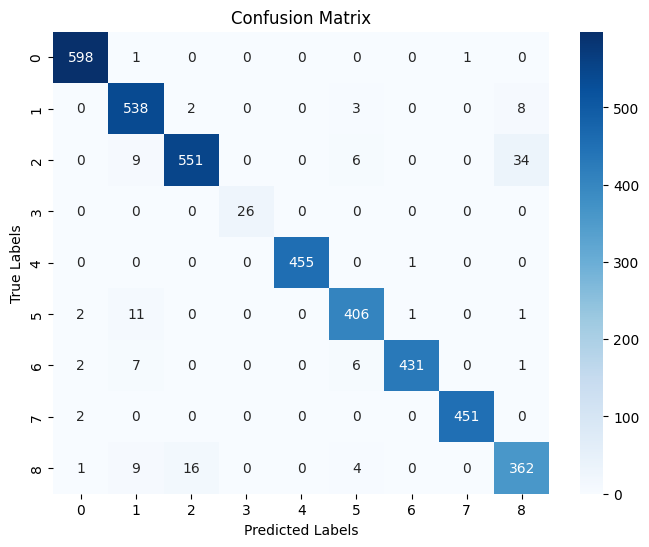

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(voting_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()